# MNIST Digit Classifier (PyTorch)
This notebook trains a simple neural network on MNIST and saves the model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [2]:
transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root="data",train=True,download=True,transform=transform)
test_dataset=datasets.MNIST(root="data",train=False,download=True,transform=transform)

train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 23.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 595kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [3]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten=nn.Flatten()
        self.fc1=nn.Linear(28*28,128)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(128,10)

    def forward(self,x):
        x=self.flatten(x)
        x=self.fc1(x)
        x=self.relu(x)
        x=self.fc2(x)
        return x

model=NeuralNet().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


In [4]:
epochs=5
train_losses=[]

for epoch in range(epochs):
    model.train()
    running_loss=0.0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)

        outputs=model(images)
        loss=criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    epoch_loss=running_loss/len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")


Epoch 1/5 Loss: 0.3479
Epoch 2/5 Loss: 0.1565
Epoch 3/5 Loss: 0.1097
Epoch 4/5 Loss: 0.0829
Epoch 5/5 Loss: 0.0653


In [5]:
model.eval()
correct=0
total=0

with torch.no_grad():
    for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        outputs=model(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()

accuracy=100*correct/total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.52%


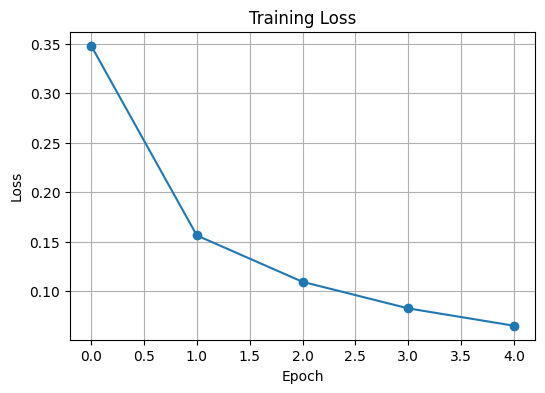

In [6]:
plt.figure(figsize=(6,4))
plt.plot(train_losses,marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [7]:
torch.save(model.state_dict(),"mnist_model.pth")
print("Model saved as mnist_model.pth")


Model saved as mnist_model.pth


In [8]:
new_model=NeuralNet().to(device)
new_model.load_state_dict(torch.load("mnist_model.pth",map_location=device))
new_model.eval()

image,label=test_dataset[0]
with torch.no_grad():
    output=new_model(image.unsqueeze(0).to(device))
    prediction=output.argmax(1).item()

print("Actual:",label)
print("Predicted:",prediction)


Actual: 7
Predicted: 7
